# Memoria Litteraria: Análise de Séries Temporais do Comportamento de Usuários

Este notebook apresenta a implementação parcial do projeto, com foco em análise temporal do uso da plataforma.

## Contexto
O Memoria Litteraria é uma aplicação web voltada à análise de textos literários e recomendação de conteúdos. Os dados de uso são analisados como séries temporais para identificar padrões de comportamento.

## Referencial Teórico
**Bhagirathi & Kiran (2025):** recomendação com KNN melhora precisão.

**DataCamp (2024):** dados educacionais permitem personalização.

**Santos (2024):** modelagem de dados melhora análise textual.

**Séries temporais:** permitem identificar tendência, sazonalidade e ruído.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.plotting import autocorrelation_plot

In [2]:
np.random.seed(42)
datas = pd.date_range(start='2026-03-01', periods=60)
dados = []
usuarios = list(range(1, 11))
livros = ['Iracema','Vidas Secas','O Guarani','Policarpo Quaresma']
funcionalidades = ['Leitura','Escrita','Citação']
for data in datas:
    for _ in range(np.random.randint(5, 15)):
        dados.append({'UsuarioId': np.random.choice(usuarios),
                      'Data': data,
                      'Livro': np.random.choice(livros),
                      'Funcionalidade': np.random.choice(funcionalidades),
                      'Avaliacao': np.random.randint(3,6)})
df = pd.DataFrame(dados)
df.head()

,UsuarioId,Data,Livro,Funcionalidade,Avaliacao
0,4,2026-03-01,Iracema,Citação,5
1,8,2026-03-01,Iracema,Leitura,5
2,10,2026-03-01,O Guarani,Citação,5
3,8,2026-03-01,Iracema,Citação,4
4,5,2026-03-01,Vidas Secas,Escrita,4


## Análise Exploratória
Base com 60 dias de interação.
Limitações: poucos usuários e dados simulados.

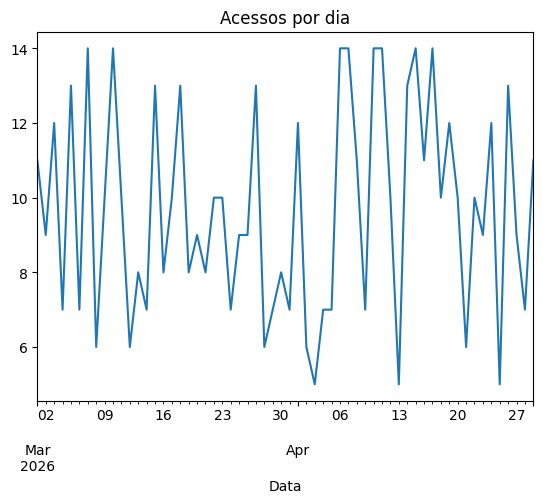

In [3]:
serie = df.groupby('Data').size()
serie.plot(title='Acessos por dia')
plt.show()

## Média Móvel
Aplicada para suavizar a série e destacar a tendência.

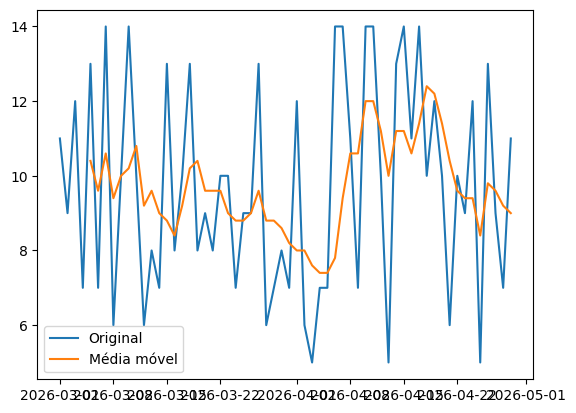

In [4]:
ma = serie.rolling(window=5).mean()
plt.plot(serie, label='Original')
plt.plot(ma, label='Média móvel')
plt.legend()
plt.show()

## Autocorrelação
Permite verificar dependência entre os valores ao longo do tempo.

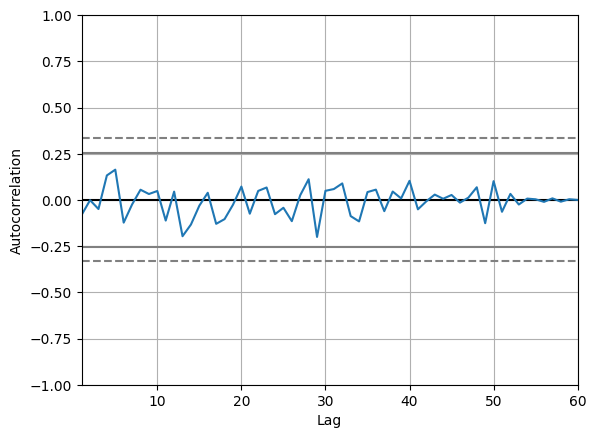

In [5]:
autocorrelation_plot(serie)
plt.show()

## Decomposição
Separação em tendência, sazonalidade e resíduo.

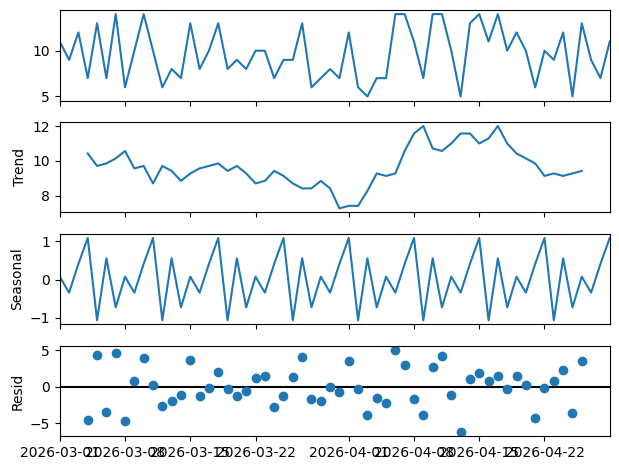

In [6]:
decomposicao = seasonal_decompose(serie, model='additive', period=7)
decomposicao.plot()
plt.show()

## Análise dos Resultados
- Tendência levemente crescente.
- Presença de variações periódicas.
- Dependência temporal identificada.

Esses padrões indicam comportamento estruturado dos usuários ao longo do tempo.

## Pipeline
Coleta → Organização temporal → Análise → Suavização → Decomposição → Interpretação

## Referências
BHAGIRATHI, S.; KIRAN, M. (2025).
DATACAMP (2024).
SANTOS, A. (2024).
COELHO, T. Memoria Litteraria (GitHub).
UNESCO (2020).
BOX; COX (1964).
GUERRERO (1993).